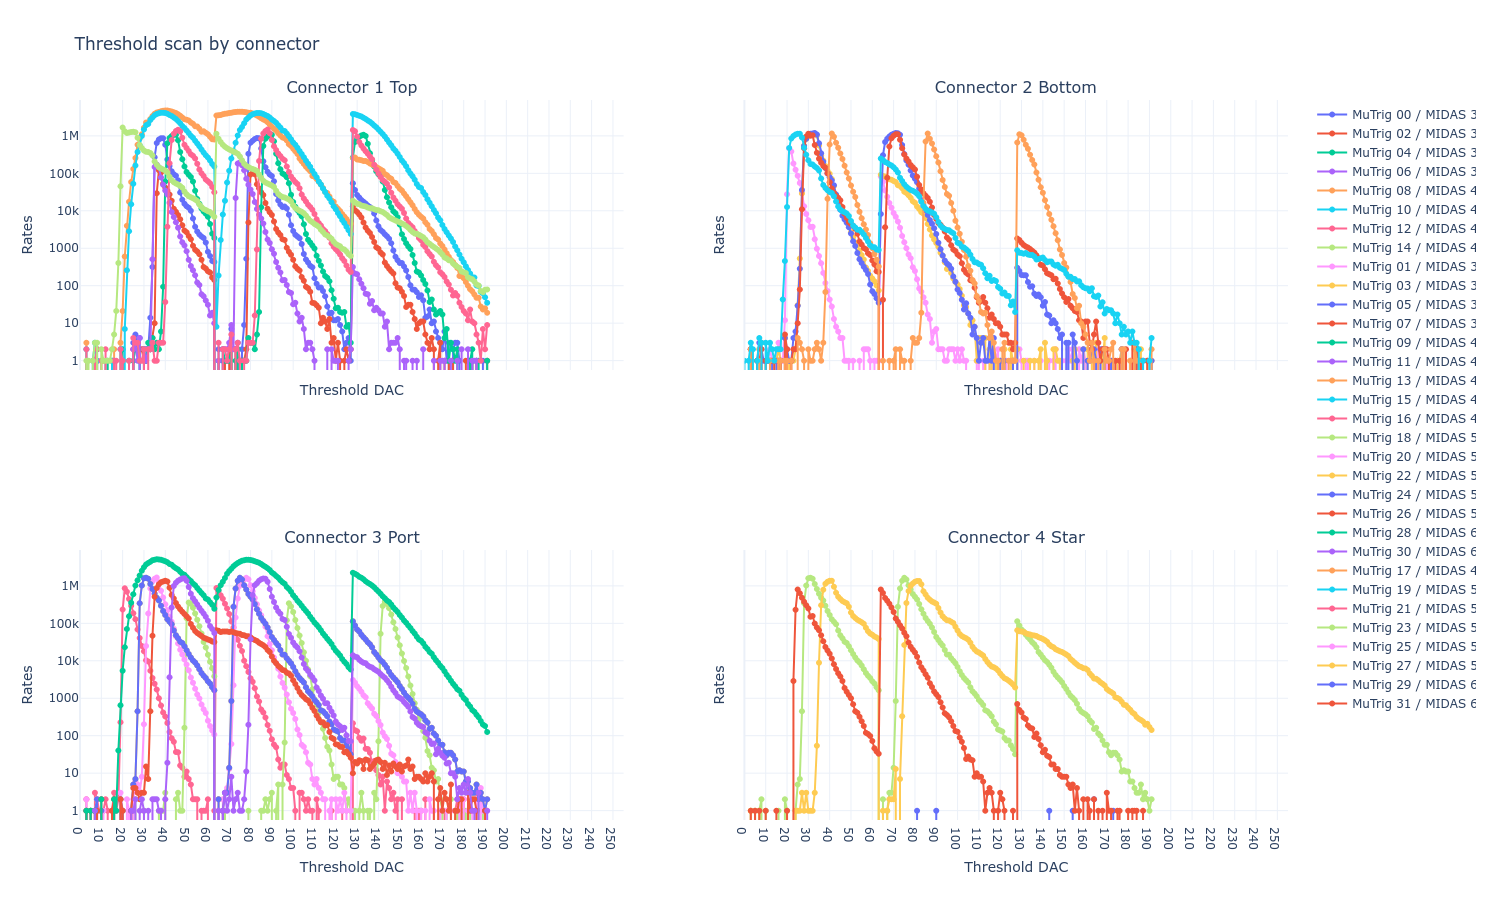

In [65]:
# Threshold scan display, MIDAS channel -> MuTrig channel mapping

import json
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots


FILENAME = "/home/nemu/musip/scripts/MutrigScripts/data/FP_adptrB.json"

FIRST_MIDAS_CHANNEL = 32     # first MIDAS channel corresponding to MuTrig 00
N_MUTRIG_CHANNELS = 32
PLOT_BY_CON = True           # True: connector layout, False: MuTrig groups 00-07, 08-15, ...

CONNECTORS = {
    "Connector 1 Top":    list(range(0, 16, 2)),
    "Connector 2 Bottom": list(range(1, 16, 2)),
    "Connector 3 Port":   list(range(16, 32, 2)),
    "Connector 4 Star":   list(range(17, 32, 2)),
}

GROUPS = {
    "MuTrig 00-07": list(range(0, 8)),
    "MuTrig 08-15": list(range(8, 16)),
    "MuTrig 16-23": list(range(16, 24)),
    "MuTrig 24-31": list(range(24, 32)),
}

with open(FILENAME, "r") as f:
    data = json.load(f)

plot_groups = CONNECTORS if PLOT_BY_CON else GROUPS

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=list(plot_groups.keys()),
    shared_xaxes=True,
    shared_yaxes=True,
)

all_rates = []

for i, (title, mutrig_channels) in enumerate(plot_groups.items()):
    row = i // 2 + 1
    col = i % 2 + 1

    for mt in mutrig_channels:
        midas = FIRST_MIDAS_CHANNEL + mt

        if midas >= len(data["th"]) or midas >= len(data["rates"]):
            continue
        if len(data["th"][midas]) == 0 or len(data["rates"][midas]) == 0:
            continue

        th = np.array(data["th"][midas])
        rates = np.array(data["rates"][midas])
        all_rates.extend(rates[rates > 0])

        fig.add_trace(
            go.Scatter(
                x=th,
                y=rates,
                mode="lines+markers",
                name=f"MuTrig {mt:02d} / MIDAS {midas}",
                hovertemplate=(
                    f"MuTrig {mt:02d}<br>"
                    f"MIDAS {midas}<br>"
                    "Threshold DAC: %{x}<br>"
                    "Rate: %{y:.3g}<extra></extra>"
                ),
            ),
            row=row,
            col=col,
        )

yrange = [-1, 5]
if len(all_rates):
    yrange = [
        np.log10(min(all_rates)) - 0.25,
        np.log10(max(all_rates)) + 0.25,
    ]

fig.update_xaxes(
    title_text="Threshold DAC",
    range=[0, 255],
    tickmode="linear",
    dtick=10,
)

fig.update_yaxes(
    title_text="Rates",
    type="log",
    range=yrange,
)

fig.update_layout(
    title=(
        "Threshold scan by connector"
        if PLOT_BY_CON else
        "Threshold scan by MuTrig channel group"
    ),
    height=900,
    width=1400,
    template="plotly_white",
    hovermode="closest",
    legend=dict(
        groupclick="toggleitem",
        itemclick="toggle",
        itemdoubleclick="toggleothers",
    ),
)

fig.show()